Writing IIR filter coefficients to /home/brandon/git/projects/OrbitESC/src/control/gen/iir_coeffs.h


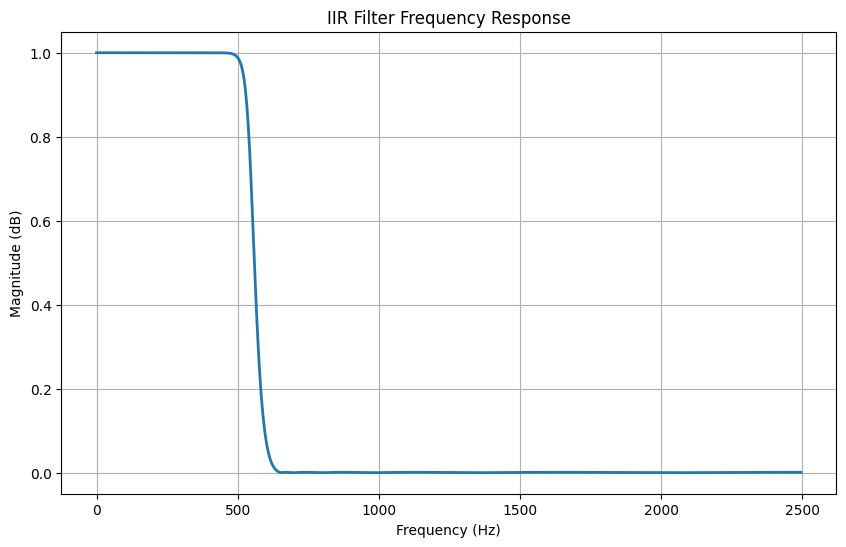

In [22]:
import os
from numpy import pi, absolute
from scipy import signal
from pylab import figure, plot, xlabel, ylabel, title, grid
from sk_dsp_comm import coeff2header
from pathlib import Path

# Define the filter specifications
sample_freq = 5000  # Sampling frequency in Hz
nyq_rate = sample_freq / 2.0  # Nyquist rate
pass_freq = 500   # Pass band frequency
transition_freq = 150  # Transition band frequency
stop_freq = pass_freq + transition_freq     # Stop band frequency
passband_ripple = 0.1  # Passband ripple in dB
stopband_atten = 60    # Stopband attenuation in dB

# Design the IIR filter
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.iirdesign.html
system = signal.iirdesign(wp=pass_freq, ws=stop_freq, gpass=passband_ripple, gstop=stopband_atten,
                          analog=False, ftype='cheby2', output='sos', fs=sample_freq)

# Extract the filter coefficients
# https://dsp.stackexchange.com/questions/79021/iir-design-scipy-cmsis-dsp-coefficient-format
# https://ece.uccs.edu/~mwickert/ece5655/lecture_notes/ARM/IIR_Lab5.pdf
# https://scikit-dsp-comm.readthedocs.io/en/docs/coeff2header.html
output_file = Path(os.getcwd()).resolve().parent / "src/control/gen/iir_coeffs.h"
print(f"Writing IIR filter coefficients to {output_file.as_posix()}")
coeff2header.iir_sos_header(output_file.as_posix(), system)

# Compute the frequency response
w, h = signal.sosfreqz(system)

# Plot the frequency response
figure(figsize=(10, 6))
plot((w/pi)*nyq_rate, absolute(h), linewidth=2)
xlabel('Frequency (Hz)')
ylabel('Magnitude (dB)')
title('IIR Filter Frequency Response')
grid(True)